<a href="https://colab.research.google.com/github/roshnik1610/machine-learning-projects/blob/main/Covid_19_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df= pd.read_csv("/content/Covid_19_Clean_Complete (1).csv")

In [3]:
df

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.939110,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.153300,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.033900,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.506300,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.202700,17.873900,2020-01-22,0,0,0,0,Africa
...,...,...,...,...,...,...,...,...,...,...
49063,NaN,Sao Tome and Principe,0.186400,6.613100,2020-07-27,865,14,734,117,Africa
49064,NaN,Yemen,15.552727,48.516388,2020-07-27,1691,483,833,375,Eastern Mediterranean
49065,NaN,Comoros,-11.645500,43.333300,2020-07-27,354,7,328,19,Africa
49066,NaN,Tajikistan,38.861000,71.276100,2020-07-27,7235,60,6028,1147,Europe


In [4]:

df.isnull().sum()

,0
Province/State,34404
Country/Region,0
Lat,0
Long,0
Date,0
Confirmed,0
Deaths,0
Recovered,0
Active,0
WHO Region,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Province/State  14664 non-null  object 
 1   Country/Region  49068 non-null  object 
 2   Lat             49068 non-null  float64
 3   Long            49068 non-null  float64
 4   Date            49068 non-null  object 
 5   Confirmed       49068 non-null  int64  
 6   Deaths          49068 non-null  int64  
 7   Recovered       49068 non-null  int64  
 8   Active          49068 non-null  int64  
 9   WHO Region      49068 non-null  object 
dtypes: float64(2), int64(4), object(4)
memory usage: 3.7+ MB


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.rename(columns={'Province/State':'State','Country/Region':'Country','WHO Region':'WHO'}, inplace= True)

In [8]:


df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   State      14664 non-null  object 
 1   Country    49068 non-null  object 
 2   Lat        49068 non-null  float64
 3   Long       49068 non-null  float64
 4   Date       49068 non-null  object 
 5   Confirmed  49068 non-null  int64  
 6   Deaths     49068 non-null  int64  
 7   Recovered  49068 non-null  int64  
 8   Active     49068 non-null  int64  
 9   WHO        49068 non-null  object 
dtypes: float64(2), int64(4), object(4)
memory usage: 3.7+ MB


In [9]:
df.Date.value_counts()

,count
Date,
2020-01-22,261
2020-01-23,261
2020-01-24,261
2020-01-25,261
2020-01-26,261
...,...
2020-07-23,261
2020-07-24,261
2020-07-25,261


In [10]:
top= df[df['Date']=='2020-07-27']
top

,State,Country,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO
48807,NaN,Afghanistan,33.939110,67.709953,2020-07-27,36263,1269,25198,9796,Eastern Mediterranean
48808,NaN,Albania,41.153300,20.168300,2020-07-27,4880,144,2745,1991,Europe
48809,NaN,Algeria,28.033900,1.659600,2020-07-27,27973,1163,18837,7973,Africa
48810,NaN,Andorra,42.506300,1.521800,2020-07-27,907,52,803,52,Europe
48811,NaN,Angola,-11.202700,17.873900,2020-07-27,950,41,242,667,Africa
...,...,...,...,...,...,...,...,...,...,...
49063,NaN,Sao Tome and Principe,0.186400,6.613100,2020-07-27,865,14,734,117,Africa
49064,NaN,Yemen,15.552727,48.516388,2020-07-27,1691,483,833,375,Eastern Mediterranean
49065,NaN,Comoros,-11.645500,43.333300,2020-07-27,354,7,328,19,Africa
49066,NaN,Tajikistan,38.861000,71.276100,2020-07-27,7235,60,6028,1147,Europe


In [11]:

top.groupby(by='Country')[['Confirmed','Deaths','Recovered','Active']].sum().reset_index()

,Country,Confirmed,Deaths,Recovered,Active
0,Afghanistan,36263,1269,25198,9796
1,Albania,4880,144,2745,1991
2,Algeria,27973,1163,18837,7973
3,Andorra,907,52,803,52
4,Angola,950,41,242,667
...,...,...,...,...,...
182,West Bank and Gaza,10621,78,3752,6791
183,Western Sahara,10,1,8,1
184,Yemen,1691,483,833,375
185,Zambia,4552,140,2815,1597


In [12]:
Confirmed= df.groupby(by='Date')['Confirmed'].sum().reset_index()

In [13]:
Confirmed

,Date,Confirmed
0,2020-01-22,555
1,2020-01-23,654
2,2020-01-24,941
3,2020-01-25,1434
4,2020-01-26,2118
...,...,...
183,2020-07-23,15510481
184,2020-07-24,15791645
185,2020-07-25,16047190
186,2020-07-26,16251796


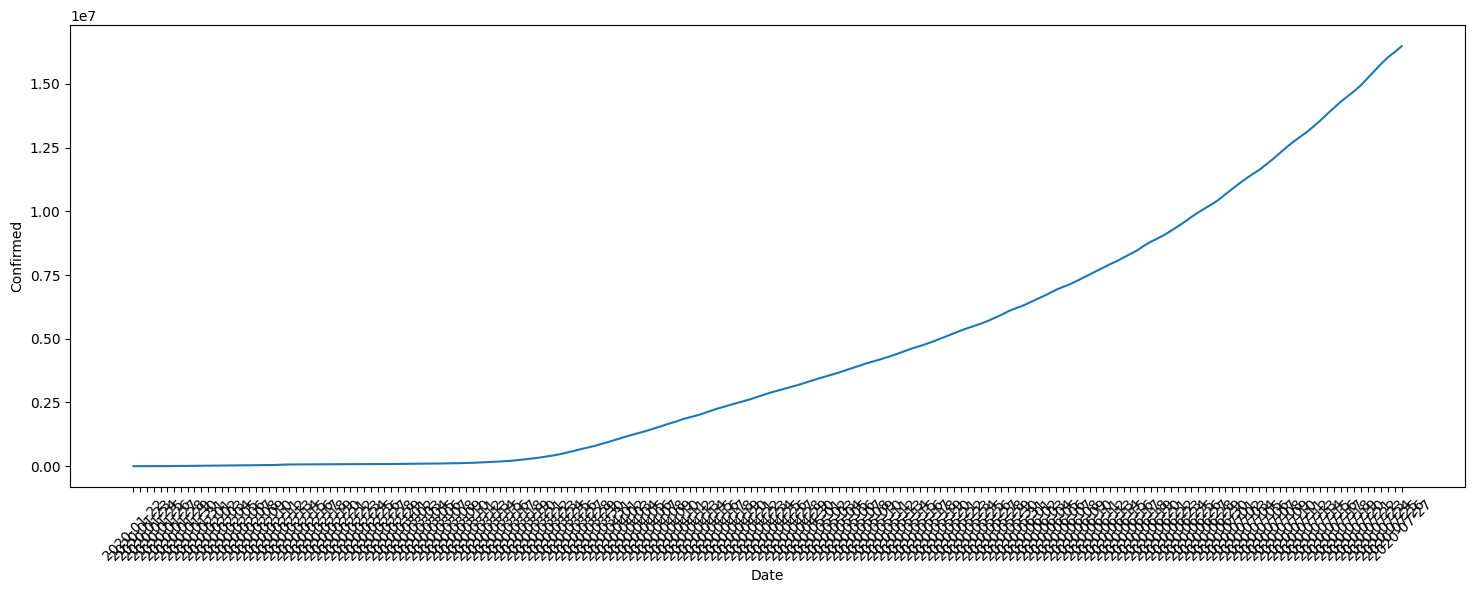

In [14]:
#visualizing confirmed case
plt.figure(figsize=(18,6))
sns.lineplot(data= Confirmed,x='Date', y='Confirmed')
plt.xticks(rotation=45)
plt.show()

#**Top 10 countries**

In [15]:
top_10_recovered= df.groupby(by="Country")["Recovered"].sum().sort_values(ascending=False).head(10).reset_index()

In [16]:
top_10_recovered

,Country,Recovered
0,US,56353416
1,Brazil,54492873
2,Russia,25120448
3,India,23783720
4,Germany,17107839
5,Italy,15673910
6,Iran,15200895
7,Spain,15093583
8,Turkey,13345389
9,Chile,13292593


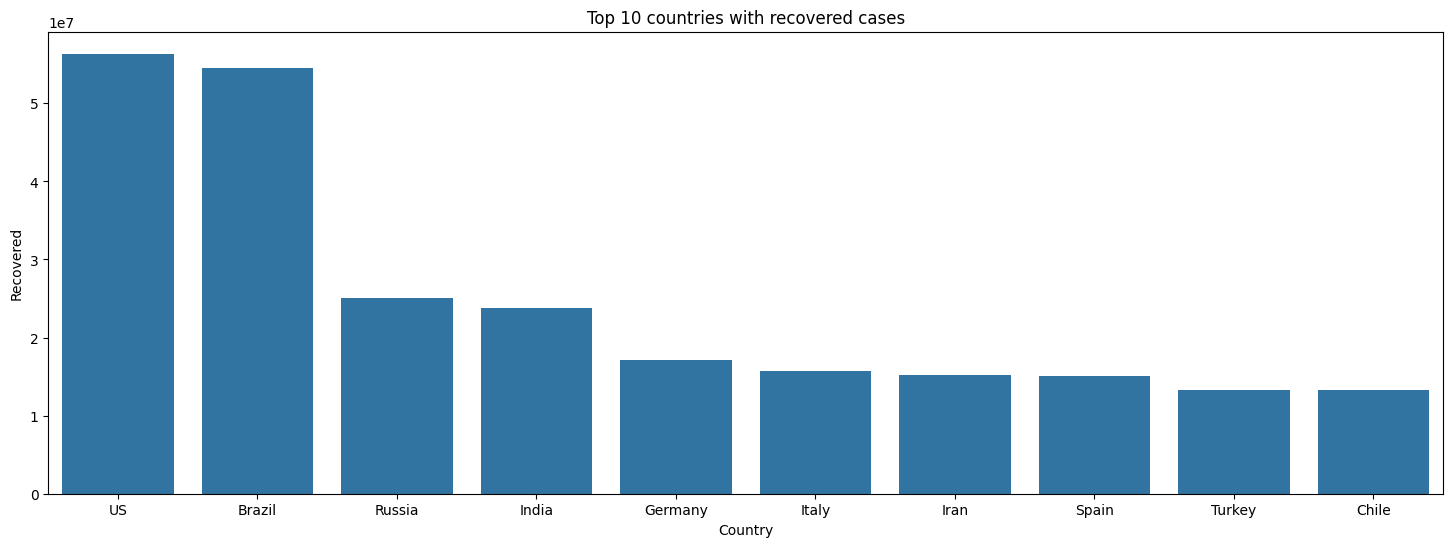

In [17]:
#visualizing recovered data
plt.figure( figsize=(18,6))
sns.barplot(data= top_10_recovered, x="Country", y="Recovered")
plt.title("Top 10 countries with recovered cases")
plt.show()

In [18]:
# top 10 death
top_10_death= df.groupby( by='Country')['Deaths'].sum().sort_values(ascending=False).head(10).reset_index()

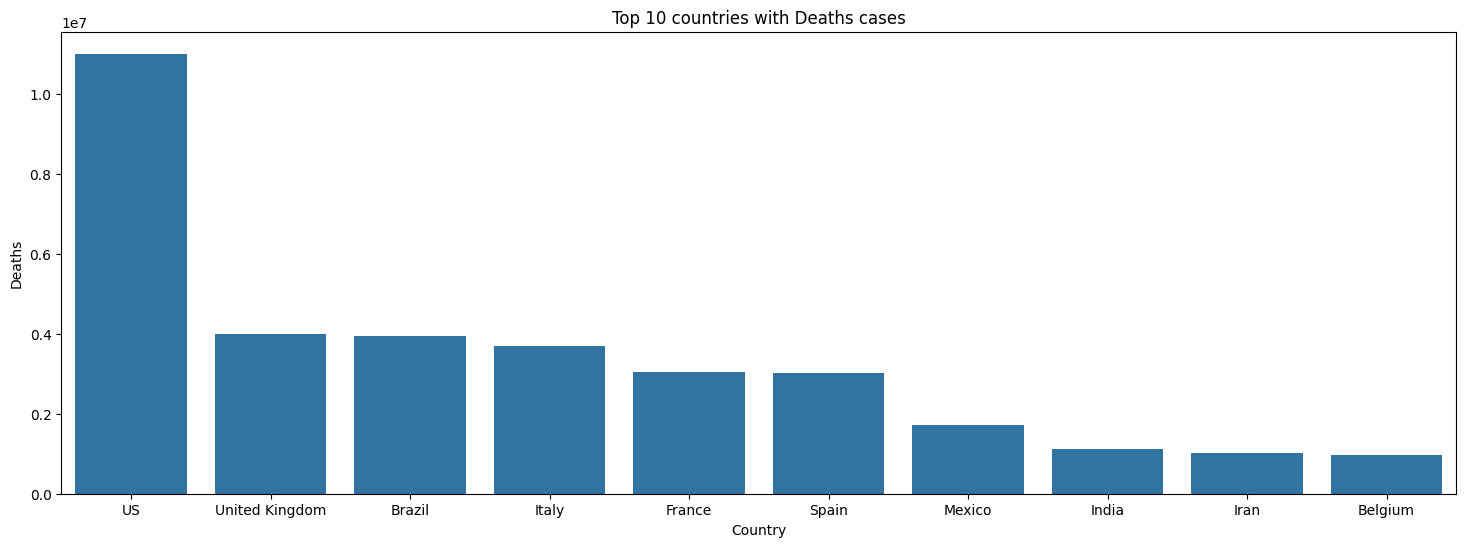

In [19]:
plt.figure( figsize=(18,6))
sns.barplot(data= top_10_death, x="Country", y="Deaths")
plt.title("Top 10 countries with Deaths cases")
plt.show()

In [20]:
# country with most active cases
top_10_active= df.groupby(by="Country")["Active"].sum().sort_values(ascending=False).head(10).reset_index()

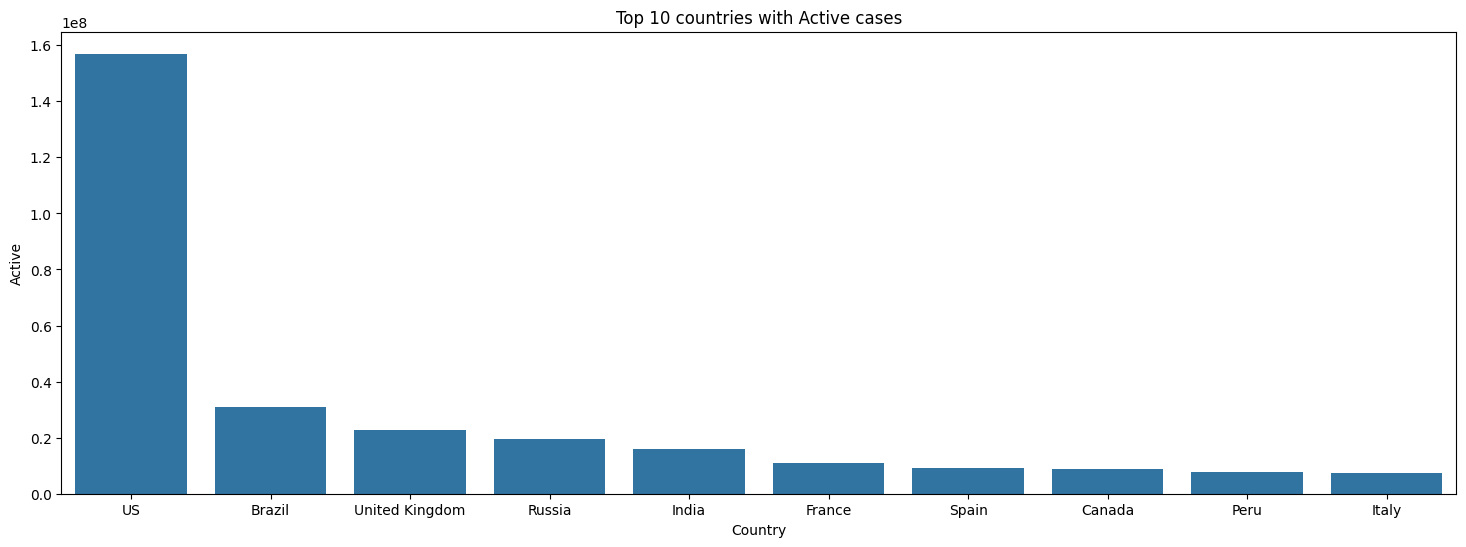

In [21]:
plt.figure( figsize=(18,6))
sns.barplot(data= top_10_active, x="Country", y="Active")
plt.title("Top 10 countries with Active cases")
plt.show()

In [22]:
#country wise analysis
#1. usa
#2. china
#3. india

In [23]:
us= df[df["Country"]=="US"]
us.head()

,State,Country,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO
223,NaN,US,40.0,-100.0,2020-01-22,1,0,0,1,Americas
484,NaN,US,40.0,-100.0,2020-01-23,1,0,0,1,Americas
745,NaN,US,40.0,-100.0,2020-01-24,2,0,0,2,Americas
1006,NaN,US,40.0,-100.0,2020-01-25,2,0,0,2,Americas
1267,NaN,US,40.0,-100.0,2020-01-26,5,0,0,5,Americas


In [24]:
us= us.groupby( by="Date")[['Confirmed','Deaths','Recovered','Active']].sum().reset_index()

In [25]:
us

,Date,Confirmed,Deaths,Recovered,Active
0,2020-01-22,1,0,0,1
1,2020-01-23,1,0,0,1
2,2020-01-24,2,0,0,2
3,2020-01-25,2,0,0,2
4,2020-01-26,5,0,0,5
...,...,...,...,...,...
183,2020-07-23,4038816,144430,1233269,2661117
184,2020-07-24,4112531,145560,1261624,2705347
185,2020-07-25,4178970,146465,1279414,2753091
186,2020-07-26,4233923,146935,1297863,2789125


In [26]:

china= df[df["Country"]=="China"]
china.head()

,State,Country,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO
48,Anhui,China,31.8257,117.2264,2020-01-22,1,0,0,1,Western Pacific
49,Beijing,China,40.1824,116.4142,2020-01-22,14,0,0,14,Western Pacific
50,Chongqing,China,30.0572,107.8740,2020-01-22,6,0,0,6,Western Pacific
51,Fujian,China,26.0789,117.9874,2020-01-22,1,0,0,1,Western Pacific
52,Gansu,China,35.7518,104.2861,2020-01-22,0,0,0,0,Western Pacific


In [27]:
china= china.groupby(by='Date')[['Confirmed',"Deaths","Recovered","Active"]].sum().reset_index()

In [28]:
china

,Date,Confirmed,Deaths,Recovered,Active
0,2020-01-22,548,17,28,503
1,2020-01-23,643,18,30,595
2,2020-01-24,920,26,36,858
3,2020-01-25,1406,42,39,1325
4,2020-01-26,2075,56,49,1970
...,...,...,...,...,...
183,2020-07-23,86045,4649,78701,2695
184,2020-07-24,86202,4650,78745,2807
185,2020-07-25,86381,4652,78813,2916
186,2020-07-26,86570,4652,78862,3056


In [29]:
india= df[df["Country"]=="India"]
india

,State,Country,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO
129,NaN,India,20.593684,78.96288,2020-01-22,0,0,0,0,South-East Asia
390,NaN,India,20.593684,78.96288,2020-01-23,0,0,0,0,South-East Asia
651,NaN,India,20.593684,78.96288,2020-01-24,0,0,0,0,South-East Asia
912,NaN,India,20.593684,78.96288,2020-01-25,0,0,0,0,South-East Asia
1173,NaN,India,20.593684,78.96288,2020-01-26,0,0,0,0,South-East Asia
...,...,...,...,...,...,...,...,...,...,...
47892,NaN,India,20.593684,78.96288,2020-07-23,1288108,30601,817209,440298,South-East Asia
48153,NaN,India,20.593684,78.96288,2020-07-24,1337024,31358,849432,456234,South-East Asia
48414,NaN,India,20.593684,78.96288,2020-07-25,1385635,32060,885573,468002,South-East Asia
48675,NaN,India,20.593684,78.96288,2020-07-26,1435616,32771,917568,485277,South-East Asia


In [30]:
india= india.groupby(by="Date")[['Confirmed','Deaths','Recovered','Active']].sum().reset_index()

In [31]:
india

,Date,Confirmed,Deaths,Recovered,Active
0,2020-01-22,0,0,0,0
1,2020-01-23,0,0,0,0
2,2020-01-24,0,0,0,0
3,2020-01-25,0,0,0,0
4,2020-01-26,0,0,0,0
...,...,...,...,...,...
183,2020-07-23,1288108,30601,817209,440298
184,2020-07-24,1337024,31358,849432,456234
185,2020-07-25,1385635,32060,885573,468002
186,2020-07-26,1435616,32771,917568,485277


#**comparing the countries**

Text(0, 0.5, 'no of recovered')

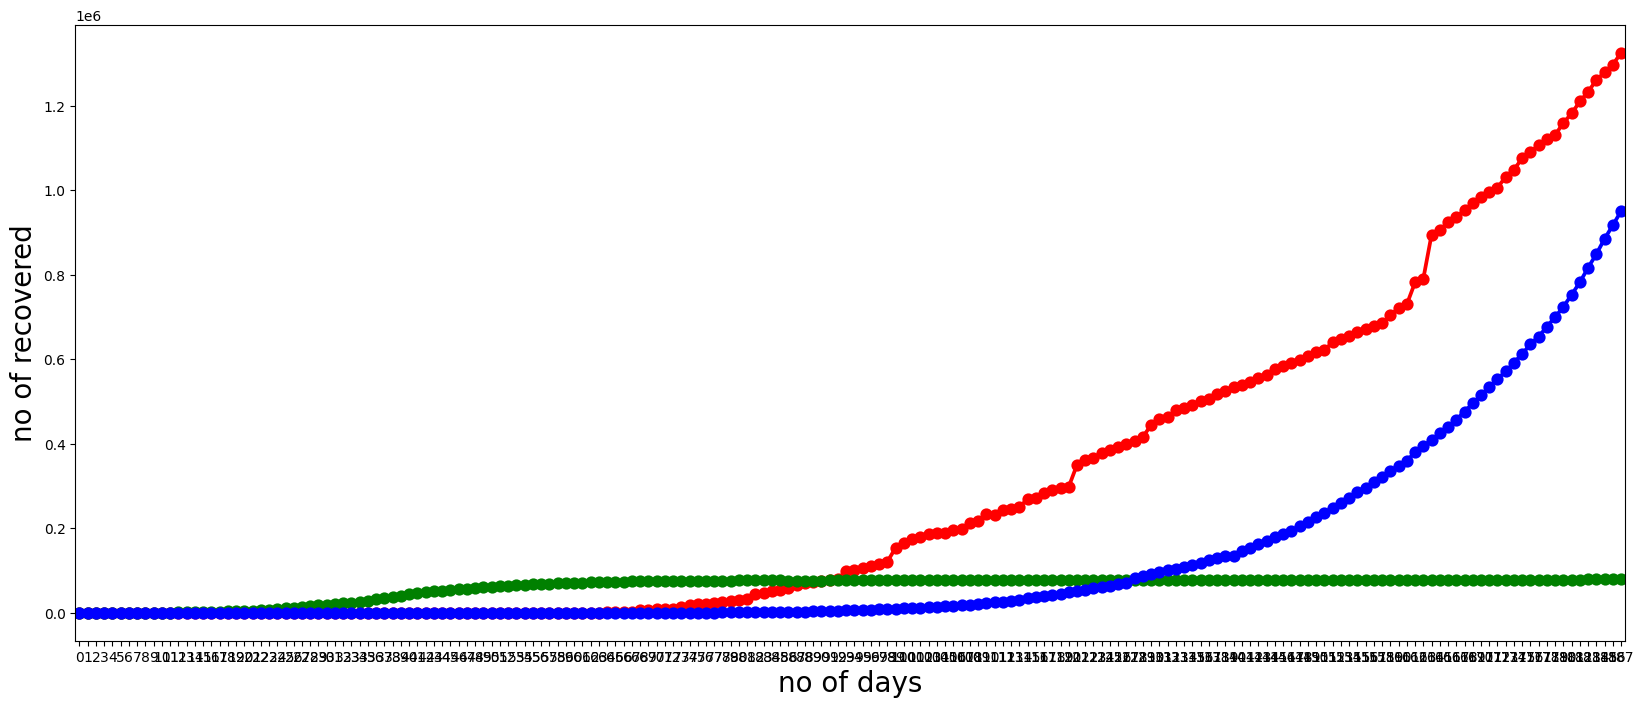

In [32]:
# compare the countries on based on the recovered cases
plt.figure(figsize=(20,8))
sns.pointplot(x=us.index,y=us.Recovered, color= "red")
sns.pointplot(x=china.index,y=china.Recovered, color= "green")
sns.pointplot(x=india.index,y=india.Recovered, color= "blue")
plt.xlabel("no of days", fontsize=20)
plt.ylabel("no of recovered", fontsize=20)

Text(0, 0.5, ' no of Deaths')

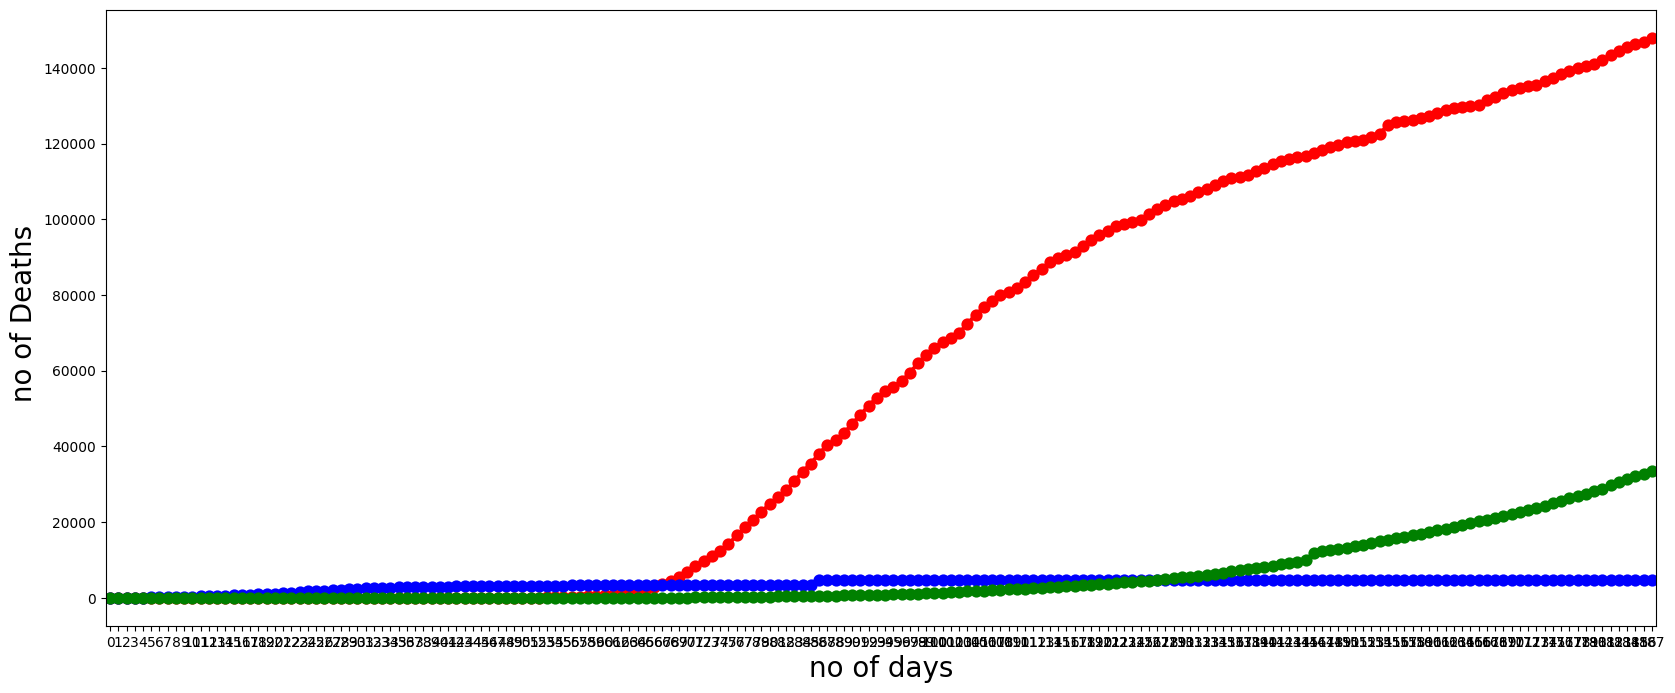

In [33]:
# compare the countries on the based of death cases
plt.figure(figsize=(20,8))
sns.pointplot( x= us.index, y=us.Deaths,color="red")
sns.pointplot(x= china.index, y= china.Deaths, color="blue")
sns.pointplot(x= india.index, y=india.Deaths, color="green")
plt.xlabel("no of days", fontsize=20)
plt.ylabel(" no of Deaths", fontsize= 20)

Text(0, 0.5, ' no of Deaths')

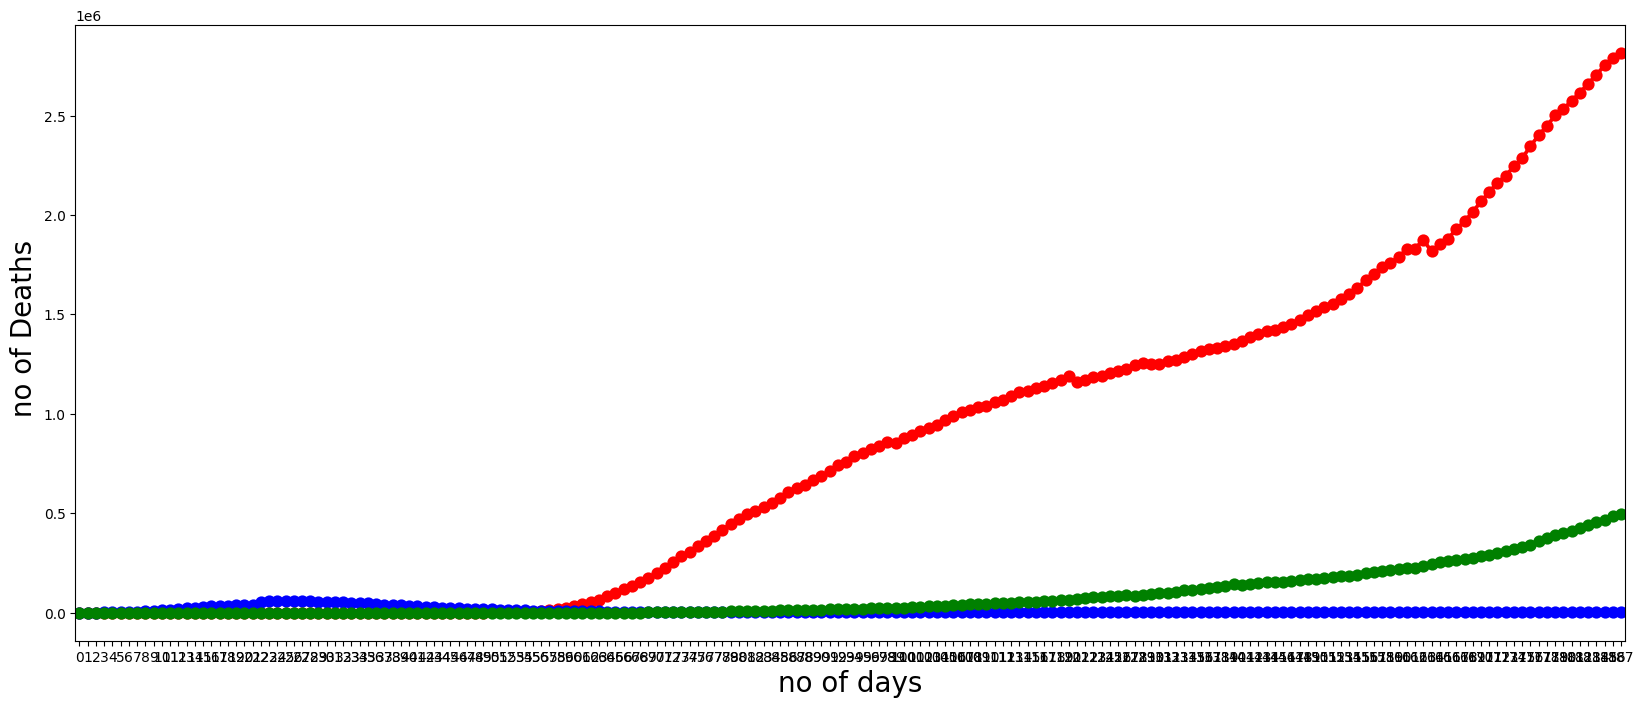

In [34]:




# compare the countries on the based of active cases
plt.figure(figsize=(20,8))
sns.pointplot( x= us.index, y=us.Active,color="red")
sns.pointplot(x= china.index, y= china.Active, color="blue")
sns.pointplot(x= india.index, y=india.Active, color="green")
plt.xlabel("no of days", fontsize=20)
plt.ylabel(" no of Deaths", fontsize= 20)

In [35]:
!pip install prophet
''' prophet is a time series forecasting toool that is designed to be easy to use and effective for a wide range of  time series data.
its particulary useful for data that has strong seasonal effects( like daily or weekly patterns) and includes important dates or events that can impact the forecast. '''

' prophet is a time series forecasting toool that is designed to be easy to use and effective for a wide range of  time series data.\nits particulary useful for data that has strong seasonal effects( like daily or weekly patterns) and includes important dates or events that can impact the forecast. '

In [36]:
df1= pd.read_csv("/content/Covid_19_Clean_Complete (1).csv", parse_dates=["Date"])
df1

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.939110,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.153300,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.033900,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.506300,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.202700,17.873900,2020-01-22,0,0,0,0,Africa
...,...,...,...,...,...,...,...,...,...,...
49063,NaN,Sao Tome and Principe,0.186400,6.613100,2020-07-27,865,14,734,117,Africa
49064,NaN,Yemen,15.552727,48.516388,2020-07-27,1691,483,833,375,Eastern Mediterranean
49065,NaN,Comoros,-11.645500,43.333300,2020-07-27,354,7,328,19,Africa
49066,NaN,Tajikistan,38.861000,71.276100,2020-07-27,7235,60,6028,1147,Europe


In [37]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Province/State  14664 non-null  object        
 1   Country/Region  49068 non-null  object        
 2   Lat             49068 non-null  float64       
 3   Long            49068 non-null  float64       
 4   Date            49068 non-null  datetime64[ns]
 5   Confirmed       49068 non-null  int64         
 6   Deaths          49068 non-null  int64         
 7   Recovered       49068 non-null  int64         
 8   Active          49068 non-null  int64         
 9   WHO Region      49068 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(4), object(3)
memory usage: 3.7+ MB


In [38]:
confirmed= df1.groupby(by="Date")['Confirmed'].sum().reset_index()
confirmed

,Date,Confirmed
0,2020-01-22,555
1,2020-01-23,654
2,2020-01-24,941
3,2020-01-25,1434
4,2020-01-26,2118
...,...,...
183,2020-07-23,15510481
184,2020-07-24,15791645
185,2020-07-25,16047190
186,2020-07-26,16251796


In [39]:
deaths= df1.groupby(by="Date")['Deaths'].sum().reset_index()
deaths

,Date,Deaths
0,2020-01-22,17
1,2020-01-23,18
2,2020-01-24,26
3,2020-01-25,42
4,2020-01-26,56
...,...,...
183,2020-07-23,633506
184,2020-07-24,639650
185,2020-07-25,644517
186,2020-07-26,648621


In [40]:

active= df1.groupby( by="Date")['Active'].sum().reset_index()
active

,Date,Active
0,2020-01-22,510
1,2020-01-23,606
2,2020-01-24,879
3,2020-01-25,1353
4,2020-01-26,2010
...,...,...
183,2020-07-23,6166006
184,2020-07-24,6212290
185,2020-07-25,6243930
186,2020-07-26,6309711


In [41]:
confirmed.columns=['ds','y']
confirmed

,ds,y
0,2020-01-22,555
1,2020-01-23,654
2,2020-01-24,941
3,2020-01-25,1434
4,2020-01-26,2118
...,...,...
183,2020-07-23,15510481
184,2020-07-24,15791645
185,2020-07-25,16047190
186,2020-07-26,16251796


In [42]:
from prophet import Prophet
m= Prophet()

#**Forecasting for confirmed cases**

In [43]:
m.fit(confirmed)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [44]:
future= m.make_future_dataframe(periods=7)
forecast= m.predict(future)
forecast.tail(9)

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
186,2020-07-26,1.592907e+07,1.582863e+07,1.604632e+07,1.592907e+07,1.592907e+07,7298.791978,7298.791978,7298.791978,7298.791978,7298.791978,7298.791978,0.0,0.0,0.0,1.593637e+07
187,2020-07-27,1.613306e+07,1.602108e+07,1.623650e+07,1.613306e+07,1.613306e+07,-2102.755455,-2102.755455,-2102.755455,-2102.755455,-2102.755455,-2102.755455,0.0,0.0,0.0,1.613096e+07
188,2020-07-28,1.633705e+07,1.621953e+07,1.641954e+07,1.633705e+07,1.633705e+07,-16846.239961,-16846.239961,-16846.239961,-16846.239961,-16846.239961,-16846.239961,0.0,0.0,0.0,1.632021e+07
189,2020-07-29,1.654104e+07,1.643570e+07,1.664244e+07,1.654068e+07,1.654188e+07,-11063.558307,-11063.558307,-11063.558307,-11063.558307,-11063.558307,-11063.558307,0.0,0.0,0.0,1.652998e+07
190,2020-07-30,1.674503e+07,1.662931e+07,1.684405e+07,1.674141e+07,1.674924e+07,-1117.543863,-1117.543863,-1117.543863,-1117.543863,-1117.543863,-1117.543863,0.0,0.0,0.0,1.674392e+07
191,2020-07-31,1.694902e+07,1.685294e+07,1.706541e+07,1.694051e+07,1.695993e+07,10080.978737,10080.978737,10080.978737,10080.978737,10080.978737,10080.978737,0.0,0.0,0.0,1.695911e+07
192,2020-08-01,1.715301e+07,1.705680e+07,1.727073e+07,1.713669e+07,1.717204e+07,13750.326871,13750.326871,13750.326871,13750.326871,13750.326871,13750.326871,0.0,0.0,0.0,1.716677e+07
193,2020-08-02,1.735701e+07,1.725046e+07,1.748339e+07,1.733270e+07,1.738579e+07,7298.791978,7298.791978,7298.791978,7298.791978,7298.791978,7298.791978,0.0,0.0,0.0,1.736430e+07
194,2020-08-03,1.756100e+07,1.744001e+07,1.767734e+07,1.752702e+07,1.759883e+07,-2102.755455,-2102.755455,-2102.755455,-2102.755455,-2102.755455,-2102.755455,0.0,0.0,0.0,1.755889e+07


In [45]:
forecast_next_7_days= forecast[['ds','yhat','yhat_lower','yhat_upper']].tail(7)
forecast_next_7_days


,ds,yhat,yhat_lower,yhat_upper
188,2020-07-28,1.632021e+07,1.621953e+07,1.641954e+07
189,2020-07-29,1.652998e+07,1.643570e+07,1.664244e+07
190,2020-07-30,1.674392e+07,1.662931e+07,1.684405e+07
191,2020-07-31,1.695911e+07,1.685294e+07,1.706541e+07
192,2020-08-01,1.716677e+07,1.705680e+07,1.727073e+07
193,2020-08-02,1.736430e+07,1.725046e+07,1.748339e+07
194,2020-08-03,1.755889e+07,1.744001e+07,1.767734e+07


In [46]:
'''forecast[['ds','yhat','yhat_upper','yhat_lower']]
ds= date stamp
this column cotains the date for which the predictions have been made.it stands for date stamp.

yhat:
this is the predicted value for the given date in the ds column. it represents the model's best estimate for that point in time.

yhat_upper:
this column indicates the upper bound of the predicted value. Which indicates the higher end of the confidence interval.
it suggests that actual value is unlikely to exceed this amount, giving you an idea of prediction uncertainty.

yhat_lower:
this column indicated the lower bound of the predicted value, which indicates the lower end of the confidence interval.
it suggests that actual value is unlikely to be below this amount giving you an idea of prediction unceratinty.'''


"forecast[['ds','yhat','yhat_upper','yhat_lower']]\nds= date stamp\nthis column cotains the date for which the predictions have been made.it stands for date stamp.\n\nyhat:\nthis is the predicted value for the given date in the ds column. it represents the model's best estimate for that point in time.\n\nyhat_upper:\nthis column indicates the upper bound of the predicted value. Which indicates the higher end of the confidence interval.\nit suggests that actual value is unlikely to exceed this amount, giving you an idea of prediction uncertainty.\n\nyhat_lower:\nthis column indicated the lower bound of the predicted value, which indicates the lower end of the confidence interval.\nit suggests that actual value is unlikely to be below this amount giving you an idea of prediction unceratinty."

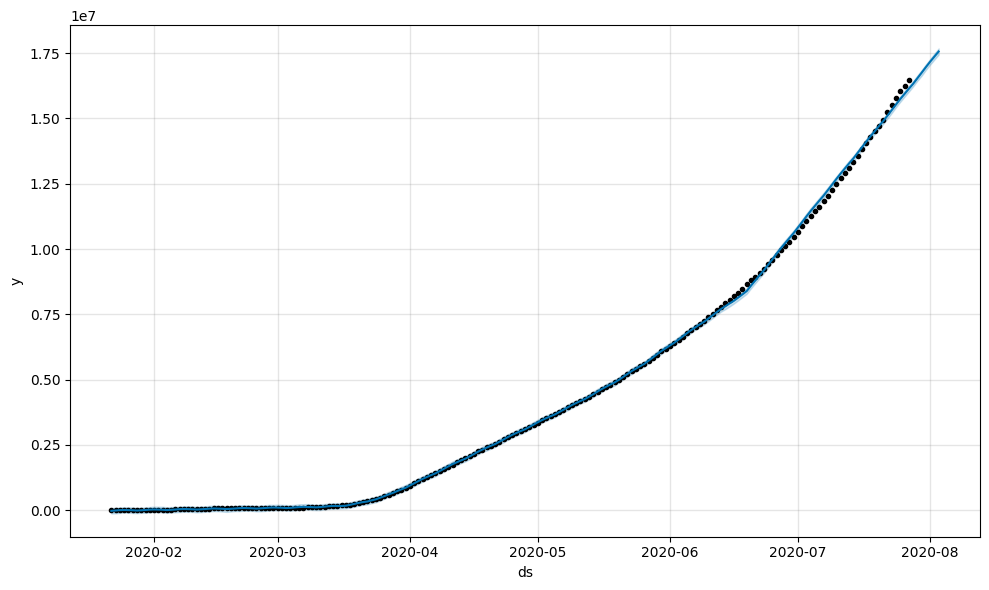

In [48]:
m.plot(forecast)
plt.show()

In [50]:
active.columns=['ds','y']
active

,ds,y
0,2020-01-22,510
1,2020-01-23,606
2,2020-01-24,879
3,2020-01-25,1353
4,2020-01-26,2010
...,...,...
183,2020-07-23,6166006
184,2020-07-24,6212290
185,2020-07-25,6243930
186,2020-07-26,6309711


In [51]:
a= Prophet()

In [53]:
a.fit(active)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [55]:
future= a.make_future_dataframe(periods=7)
forecast= a.predict(future)
forecast.tail(9)

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
186,2020-07-26,6.234752e+06,6.199540e+06,6.287312e+06,6.234752e+06,6.234752e+06,8151.913171,8151.913171,8151.913171,8151.913171,8151.913171,8151.913171,0.0,0.0,0.0,6.242904e+06
187,2020-07-27,6.297020e+06,6.250997e+06,6.342459e+06,6.297020e+06,6.297020e+06,-365.533717,-365.533717,-365.533717,-365.533717,-365.533717,-365.533717,0.0,0.0,0.0,6.296654e+06
188,2020-07-28,6.359287e+06,6.307075e+06,6.395119e+06,6.359287e+06,6.359287e+06,-5866.940936,-5866.940936,-5866.940936,-5866.940936,-5866.940936,-5866.940936,0.0,0.0,0.0,6.353420e+06
189,2020-07-29,6.421555e+06,6.370746e+06,6.467016e+06,6.420679e+06,6.422226e+06,-5734.815309,-5734.815309,-5734.815309,-5734.815309,-5734.815309,-5734.815309,0.0,0.0,0.0,6.415820e+06
190,2020-07-30,6.483822e+06,6.432203e+06,6.526508e+06,6.480914e+06,6.486168e+06,-2543.415441,-2543.415441,-2543.415441,-2543.415441,-2543.415441,-2543.415441,0.0,0.0,0.0,6.481279e+06
191,2020-07-31,6.546090e+06,6.498348e+06,6.597689e+06,6.539848e+06,6.550852e+06,3230.785517,3230.785517,3230.785517,3230.785517,3230.785517,3230.785517,0.0,0.0,0.0,6.549320e+06
192,2020-08-01,6.608357e+06,6.564513e+06,6.657239e+06,6.598329e+06,6.616855e+06,3128.006715,3128.006715,3128.006715,3128.006715,3128.006715,3128.006715,0.0,0.0,0.0,6.611485e+06
193,2020-08-02,6.670624e+06,6.632919e+06,6.728351e+06,6.656804e+06,6.682877e+06,8151.913171,8151.913171,8151.913171,8151.913171,8151.913171,8151.913171,0.0,0.0,0.0,6.678776e+06
194,2020-08-03,6.732892e+06,6.681712e+06,6.778993e+06,6.714364e+06,6.750107e+06,-365.533717,-365.533717,-365.533717,-365.533717,-365.533717,-365.533717,0.0,0.0,0.0,6.732526e+06


In [56]:
forecast_next_7_days= forecast[['ds','yhat','yhat_upper','yhat_lower']].tail(7)
forecast_next_7_days

,ds,yhat,yhat_upper,yhat_lower
188,2020-07-28,6.353420e+06,6.395119e+06,6.307075e+06
189,2020-07-29,6.415820e+06,6.467016e+06,6.370746e+06
190,2020-07-30,6.481279e+06,6.526508e+06,6.432203e+06
191,2020-07-31,6.549320e+06,6.597689e+06,6.498348e+06
192,2020-08-01,6.611485e+06,6.657239e+06,6.564513e+06
193,2020-08-02,6.678776e+06,6.728351e+06,6.632919e+06
194,2020-08-03,6.732526e+06,6.778993e+06,6.681712e+06


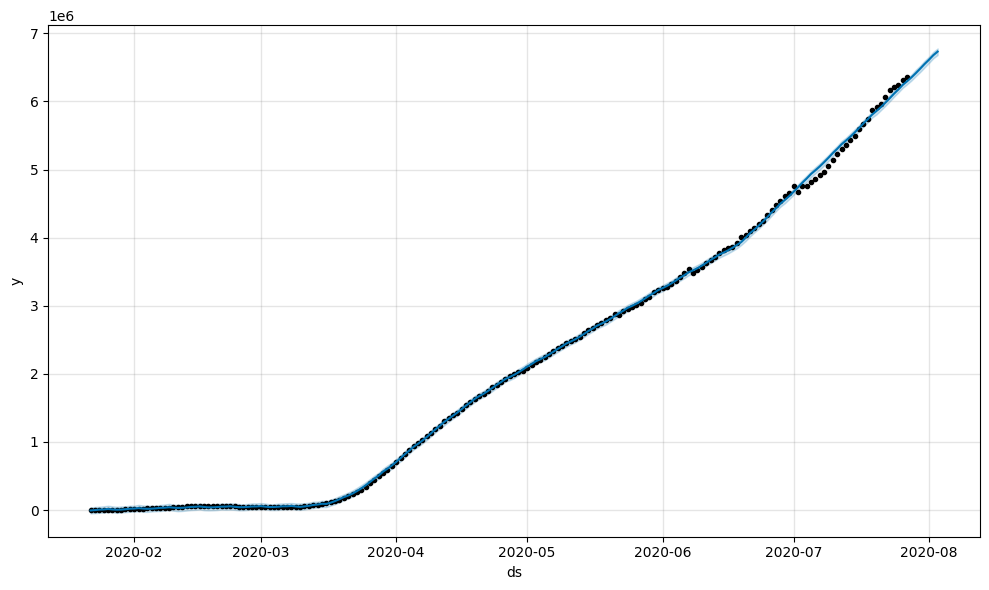

In [57]:
a.plot(forecast)
plt.show()

In [58]:
d= Prophet()


In [59]:
deaths.columns=['ds','y']
deaths

,ds,y
0,2020-01-22,17
1,2020-01-23,18
2,2020-01-24,26
3,2020-01-25,42
4,2020-01-26,56
...,...,...
183,2020-07-23,633506
184,2020-07-24,639650
185,2020-07-25,644517
186,2020-07-26,648621


In [60]:
d.fit(deaths)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [61]:
future= d.make_future_dataframe(periods=7)
forecast= d.predict(future)
forecast.tail(9)

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
186,2020-07-26,642985.098503,640950.662088,644790.193432,642985.098503,642985.098503,-165.600459,-165.600459,-165.600459,-165.600459,-165.600459,-165.600459,0.0,0.0,0.0,642819.498044
187,2020-07-27,648014.507443,645061.905361,649092.439051,648014.507443,648014.507443,-904.694278,-904.694278,-904.694278,-904.694278,-904.694278,-904.694278,0.0,0.0,0.0,647109.813166
188,2020-07-28,653043.916383,650234.299683,654261.862957,653043.916383,653043.916383,-728.343117,-728.343117,-728.343117,-728.343117,-728.343117,-728.343117,0.0,0.0,0.0,652315.573266
189,2020-07-29,658073.325323,655861.222164,659577.405178,657969.811331,658109.205888,-191.187755,-191.187755,-191.187755,-191.187755,-191.187755,-191.187755,0.0,0.0,0.0,657882.137569
190,2020-07-30,663102.734264,661547.081839,665595.389946,662751.251828,663268.492530,388.672065,388.672065,388.672065,388.672065,388.672065,388.672065,0.0,0.0,0.0,663491.406328
191,2020-07-31,668132.143204,666691.445262,671090.690555,667456.591143,668582.446990,874.264079,874.264079,874.264079,874.264079,874.264079,874.264079,0.0,0.0,0.0,669006.407283
192,2020-08-01,673161.552144,671646.060937,676132.150890,671999.559712,673979.135637,726.889465,726.889465,726.889465,726.889465,726.889465,726.889465,0.0,0.0,0.0,673888.441609
193,2020-08-02,678190.961084,675418.298499,680556.771452,676484.507137,679443.530403,-165.600459,-165.600459,-165.600459,-165.600459,-165.600459,-165.600459,0.0,0.0,0.0,678025.360624
194,2020-08-03,683220.370024,679281.441557,685112.761003,680917.843478,685001.620030,-904.694278,-904.694278,-904.694278,-904.694278,-904.694278,-904.694278,0.0,0.0,0.0,682315.675746


In [62]:
forecast_next_7_days= forecast[['ds','yhat','yhat_lower','yhat_upper']].tail(7)
forecast_next_7_days


,ds,yhat,yhat_lower,yhat_upper
188,2020-07-28,652315.573266,650234.299683,654261.862957
189,2020-07-29,657882.137569,655861.222164,659577.405178
190,2020-07-30,663491.406328,661547.081839,665595.389946
191,2020-07-31,669006.407283,666691.445262,671090.690555
192,2020-08-01,673888.441609,671646.060937,676132.150890
193,2020-08-02,678025.360624,675418.298499,680556.771452
194,2020-08-03,682315.675746,679281.441557,685112.761003


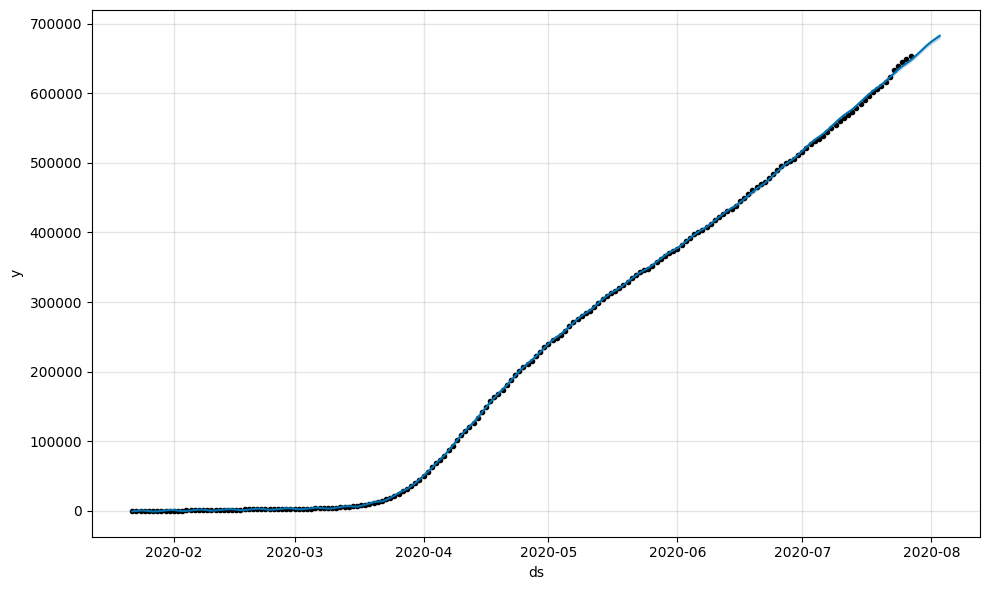

In [64]:
d.plot(forecast)
plt.show()

In [65]:
import plotly
import plotly.express as ps

In [68]:
df

,State,Country,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO
0,NaN,Afghanistan,33.939110,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.153300,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.033900,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.506300,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.202700,17.873900,2020-01-22,0,0,0,0,Africa
...,...,...,...,...,...,...,...,...,...,...
49063,NaN,Sao Tome and Principe,0.186400,6.613100,2020-07-27,865,14,734,117,Africa
49064,NaN,Yemen,15.552727,48.516388,2020-07-27,1691,483,833,375,Eastern Mediterranean
49065,NaN,Comoros,-11.645500,43.333300,2020-07-27,354,7,328,19,Africa
49066,NaN,Tajikistan,38.861000,71.276100,2020-07-27,7235,60,6028,1147,Europe


In [71]:
world= df.groupby( by='Country')[['Confirmed','Active','Deaths','Recovered']].sum().reset_index()
world

,Country,Confirmed,Active,Deaths,Recovered
0,Afghanistan,1936390,1089052,49098,798240
1,Albania,196702,72117,5708,118877
2,Algeria,1179755,345886,77972,755897
3,Andorra,94404,19907,5423,69074
4,Angola,22662,15011,1078,6573
...,...,...,...,...,...
182,West Bank and Gaza,233461,170967,1370,61124
183,Western Sahara,901,190,63,648
184,Yemen,67180,25694,17707,23779
185,Zambia,129421,43167,2643,83611


In [78]:
figure= ps.choropleth(world, locations='Country',
                      locationmode='country names',
                      color='Active',
                      hover_name='Country',
                      range_color=[1,20000],
                      color_continuous_scale='reds',
                      title='active cases'
                      )
figure.show()

In [79]:
figure= ps.choropleth(world, locations='Country',
                      locationmode='country names',
                      color='Deaths',
                      hover_name='Country',
                      range_color=[1,20000],
                      color_continuous_scale='blues',
                      title='deaths cases'
                      )
figure.show()

In [80]:
figure= ps.choropleth(world, locations='Country',
                      locationmode='country names',
                      color='Recovered',
                      hover_name='Country',
                      range_color=[1,20000],
                      color_continuous_scale='greens',
                      title='active cases'
                      )
figure.show()